# ADC 2023 Atmospheric Retrieval with JAX

This notebook demonstrates atmospheric retrieval on Ariel Data Challenge 2023 data using a fully differentiable JAX forward model.

**What this does:**
1. Loads observed spectrum from ADC 2023 dataset
2. Creates a TauREx atmospheric model
3. Wraps it with a fully differentiable JAX forward model
4. Runs gradient-based optimization to fit atmospheric parameters
5. Compares fitted parameters to ground truth
6. Shows model comparisons vs observations

**Key Configuration (matches experiment_adc_2023.py):**
- **ADC competition parameter bounds** override TauREx narrow defaults (critical for convergence!)
- **Chi-squared loss** properly weights observations by their error bars
- **GPU-efficient mode** (`pre_interpolate_opacity=False`) for memory management

**GPU Memory Notes:**
- If you encounter GPU OOM errors, try restarting the kernel to clear memory
- The script `experiment_adc_2023.py` has the same functionality with better memory management

## Setup and Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os

# Configure JAX for float64 (recommended for atmospheric modeling)
jax.config.update("jax_enable_x64", True)

print(f"JAX device: {jax.devices()[0]}")
print(f"JAX precision: {jnp.array(1.0).dtype}")

JAX device: cuda:0
JAX precision: float64


In [2]:
# Import ADC utilities and JAX backend
from adc_jax_utils import (
    load_planet_spectrum,
    load_ground_truth,
    load_fm_ground_truth,
    load_auxiliary_data,
    create_taurex_model_from_adc_planet,
)
from jax_backend import (
    extract_fitting_params,
    full_diff_create_binned_forward_model,
    fit_with_value_and_grad_adam,
)

from taurex.util import wnwidth_to_wlwidth

# Disable TauREx logging for cleaner output
import taurex.log
taurex.log.disableLogging()

Numba not installed, using numpy instead


## Load ADC 2023 Data

Choose a planet from the ADC 2023 dataset. The training set includes planets 1-1000.

In [ ]:
# Configuration
PLANET_ID = 1000  # Change this to any planet from 1-1000
N_LAYERS = 30  # Number of atmospheric layers
N_STEPS = 1000  # Optimization steps
LEARNING_RATE = 1e-3
USE_FM_AS_GROUND_TRUTH = True

# NOTE: this is very lazy and just overwrites any prior selected initial values earlier in the code
randomize_start = False # use random starting values for fitting

# Data paths
home_directory = os.path.expanduser('~')
SPECTRAL_DATA_PATH = f"{home_directory}/code/research/taurex3/test_files/adc_2023/TrainingData/SpectralData.hdf5"
AUX_DATA_PATH = f"{home_directory}/code/research/taurex3/test_files/adc_2023/TrainingData/AuxillaryTable.csv"
GROUND_TRUTH_PATH = f"{home_directory}/code/research/taurex3/test_files/adc_2023/TrainingData/Ground Truth Package/Tracedata.hdf5"

data_dir = f"{home_directory}/code/research/taurex3/test_files/adc_2023/TrainingData"
fm_params_path = os.path.join(data_dir, 'Ground Truth Package', 'FM_Parameter_Table.csv')

print(f"Loading ADC 2023 Planet {PLANET_ID}...")

Loading ADC 2023 Planet 1000...


In [12]:
# Load spectrum
spectrum_dict = load_planet_spectrum(SPECTRAL_DATA_PATH, PLANET_ID)

wl_grid = spectrum_dict['wl_grid']
# we need to reverse this because taurex operates on wavenumbers, which would be sorted in the reverse order of the wavelengths here
obs_spectrum = spectrum_dict['spectrum'][::-1]
obs_noise = spectrum_dict['noise'][::-1] # reverse noise with spectrum
wl_width = spectrum_dict['wl_width']

print(f"Spectral data loaded:")
print(f"  Wavelength range: {wl_grid.min():.2f} - {wl_grid.max():.2f} μm")
print(f"  Number of bins: {len(wl_grid)}")
print(f"  Mean SNR: {np.mean(obs_spectrum / obs_noise):.1f}")

# Choose parameters to fit
fit_params = ['planet_radius', 'T', 'H2O', 'CO2', 'CO', 'CH4', 'NH3']

print(f"Fitting: {fit_params}")
print(f"Steps: {N_STEPS}, Learning rate: {LEARNING_RATE}")

Spectral data loaded:
  Wavelength range: 0.55 - 7.28 μm
  Number of bins: 52
  Mean SNR: 614.1
Fitting: ['planet_radius', 'T', 'H2O', 'CO2', 'CO', 'CH4', 'NH3']
Steps: 1000, Learning rate: 0.001


In [5]:
# Load ground truth parameters
if USE_FM_AS_GROUND_TRUTH:
    ground_truth = load_fm_ground_truth(fm_params_path, PLANET_ID)
else:
    ground_truth = load_ground_truth(GROUND_TRUTH_PATH, PLANET_ID, sample_method='weighted_mean') # max_weight

print("\nGround Truth Parameters:")
print(f"  Planet radius: {ground_truth['planet_radius']:.4f} R_Jup")
print(f"  Temperature: {ground_truth['planet_temp']:.1f} K")
print(f"  H2O: {ground_truth['H2O']:.3e}")
print(f"  CO2: {ground_truth['CO2']:.3e}")
print(f"  CO: {ground_truth['CO']:.3e}")
print(f"  CH4: {ground_truth['CH4']:.3e}")
print(f"  NH3: {ground_truth['NH3']:.3e}")


Ground Truth Parameters:
  Planet radius: 0.8639 R_Jup
  Temperature: 945.9 K
  H2O: 6.954e-09
  CO2: 2.784e-09
  CO: 5.223e-05
  CH4: 1.834e-06
  NH3: 9.977e-07


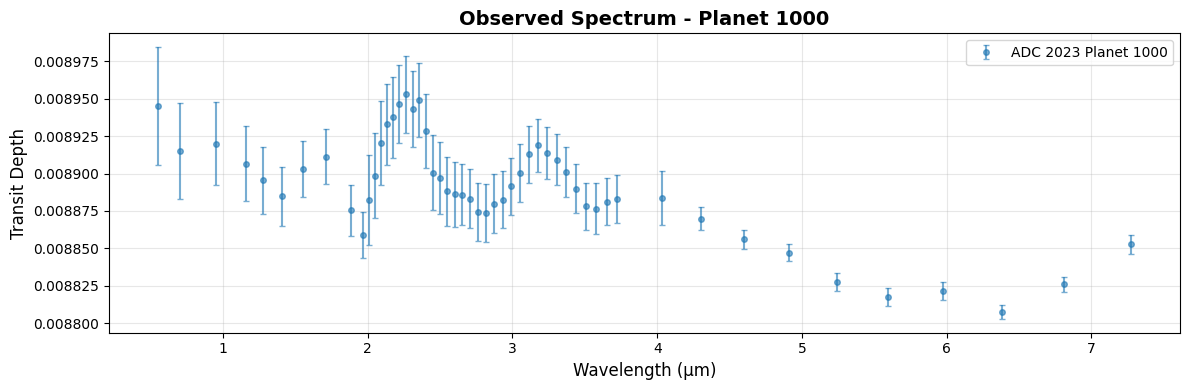

In [6]:
# Plot observed spectrum
plt.figure(figsize=(12, 4))
plt.errorbar(wl_grid, obs_spectrum, yerr=obs_noise, 
             fmt='o', alpha=0.6, markersize=4, capsize=2,
             label=f'ADC 2023 Planet {PLANET_ID}')
plt.xlabel('Wavelength (μm)', fontsize=12)
plt.ylabel('Transit Depth', fontsize=12)
plt.title(f'Observed Spectrum - Planet {PLANET_ID}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Create TauREx Model

Build an atmospheric transmission model initialized with rough guesses for the parameters.

In [7]:
# Load auxiliary data (stellar parameters, etc.)
aux_data = load_auxiliary_data(AUX_DATA_PATH, PLANET_ID)

# Setup opacity caches (required before creating TauREx model)
from taurex.cache import OpacityCache, CIACache

OpacityCache().clear_cache()
OpacityCache().set_opacity_path(f"{home_directory}/code/research/taurex3/test_files/xsec/xsec_sampled_R15000_0.3-50")
CIACache().set_cia_path(f"{home_directory}/code/research/taurex3/test_files/cia/HITRAN/data")

# Create TauREx model
tm = create_taurex_model_from_adc_planet(
    aux_data=aux_data,
    ground_truth=ground_truth,
    nlayers=N_LAYERS,
    add_clouds=False,
    add_lee_mie=False
)

print(f"\nTauREx model created:")
print(f"  Layers: {tm.nLayers}")
print(f"  Active gases: {list(tm.chemistry.activeGases)}")
print(f"  Contributions: {[c.name for c in tm.contribution_list]}")


TauREx model created:
  Layers: 30
  Active gases: ['H2O', 'CO2', 'CO', 'CH4', 'NH3']
  Contributions: ['Absorption', 'CIA', 'Rayleigh']


## Create JAX Forward Model

In [8]:
# Convert observed data to JAX arrays
obs_y = jnp.array(obs_spectrum)
obs_err = jnp.array(obs_noise)

# Create ObservedSpectrum object for the forward model
from taurex.data.spectrum.array import ArraySpectrum

# Create spectrum array: [wavelength (μm), spectrum, error]
obs_data = np.column_stack([wl_grid, obs_spectrum, obs_noise]) #, wl_width])
obs_spectrum_obj = ArraySpectrum(obs_data)

# Create the differentiable forward model
print("Creating JAX forward model (loading opacity grids)...")
forward_model = full_diff_create_binned_forward_model(tm, obs_spectrum_obj)
print("✓ Forward model ready!")

Creating JAX forward model (loading opacity grids)...
Pre-loading opacities for gases: ('H2O', 'CO2', 'CO', 'CH4', 'NH3')
Loading H2O opacity: T=27, P=22, WN=76744 (native resolution)
Loading CO2 opacity: T=27, P=22, WN=76744 (native resolution)
Loading CO opacity: T=27, P=22, WN=76744 (native resolution)
Loading CH4 opacity: T=27, P=22, WN=76744 (native resolution)
Loading NH3 opacity: T=27, P=22, WN=76744 (native resolution)
[binning] W shape: (52, 70564), empty rows: 0, partial rows: 0
[grids] high-res N=70564, bins=52, observed points=52
✓ Forward model ready!


In [9]:
obin = obs_spectrum_obj.create_binner()
taurex_obs_sectrum = obin.bin_model(tm.model(obs_spectrum_obj.wavenumberGrid))[1]

In [10]:
# Extract initial parameters with correct dtype
DTYPE = jnp.float64  # Use float64 for atmospheric modeling
params, param_info = extract_fitting_params(tm, dtype=DTYPE)

# Ensure observations use same dtype
obs_y = jnp.asarray(obs_spectrum, dtype=DTYPE)
obs_err = jnp.asarray(obs_noise, dtype=DTYPE)

print("\nInitial parameters:")
for key, value in params.items():
    info = param_info[key]
    if info['scale'] == 'log':
        print(f"  {key}: {float(value):.3e} (log scale) [{value.dtype}]")
    else:
        print(f"  {key}: {float(value):.6f} [{value.dtype}]")

adc_priors = {
    'planet_radius': [0.1, 3.0],
    'T': [0.0, 7000.0],
    'H2O': [1e-12, 0.1],
    'CO2': [1e-12, 0.1],
    'CO': [1e-12, 0.1],
    'CH4': [1e-12, 0.1],
    'NH3': [1e-12, 0.1],
    'clouds_pressure': [1e-1, 1e6],  # 0.1 Pa to 10 bar
    'lee_mie_radius': [0.001, 1.0], # 1 nm to 1 um
    'lee_mie_q': [1.0, 100.0],
    'lee_mie_mix_ratio': [1e-12, 1e-2], # Increased range
    'lee_mie_bottomP': [1e-1, 1e6],
    'lee_mie_topP': [1e-1, 1e6]
}

print('\nload bounds:')
for param_name, bounds in adc_priors.items():
    if param_name in param_info:
        old_bounds = param_info[param_name]['range']
        param_info[param_name]['range'] = bounds
        print(f"  {param_name}: {old_bounds} -> {bounds}")


Initial parameters:
  planet_mass: 1.040618 [float64]
  planet_radius: 0.863896 [float64]
  planet_distance: 0.079278 [float64]
  planet_sma: 0.079278 [float64]
  distance: 176.051000 [float64]
  atm_min_pressure: 1.000e+00 (log scale) [float64]
  atm_max_pressure: 1.000e+06 (log scale) [float64]
  T: 945.924548 [float64]
  H2O: 6.954e-09 (log scale) [float64]
  CO2: 2.784e-09 (log scale) [float64]
  CO: 5.223e-05 (log scale) [float64]
  CH4: 1.834e-06 (log scale) [float64]
  NH3: 9.977e-07 (log scale) [float64]
  He_H2: 1.720e-01 (log scale) [float64]

load bounds:
  planet_radius: [0.9, 1.1] -> [0.1, 3.0]
  T: [300.0, 2000.0] -> [0.0, 7000.0]
  H2O: [1e-12, 0.1] -> [1e-12, 0.1]
  CO2: [1e-12, 0.1] -> [1e-12, 0.1]
  CO: [1e-12, 0.1] -> [1e-12, 0.1]
  CH4: [1e-12, 0.1] -> [1e-12, 0.1]
  NH3: [1e-12, 0.1] -> [1e-12, 0.1]


In [ ]:
randomize_scale = 0.5
random_seed = 0
if randomize_start:
    print(f"\nRandomizing initial parameters (scale={randomize_scale}, seed={random_seed})...")
    
    rng = np.random.RandomState(random_seed)
    
    for param_name in fit_params:
        if param_name in param_info and param_name in params:
            bounds = param_info[param_name]['range']
            scale = param_info[param_name]['scale']
            
            if scale == 'log':
                # For log-scale parameters (mixing ratios), randomize in log space
                log_min, log_max = np.log10(bounds[0]), np.log10(bounds[1])
                log_center = (log_min + log_max) / 2
                log_range = (log_max - log_min) * randomize_scale
                log_val = log_center + rng.uniform(-log_range/2, log_range/2)
                params[param_name] = jnp.array(10**log_val, dtype=DTYPE)
            else:
                # For linear parameters (radius, temp), randomize in linear space
                center = (bounds[0] + bounds[1]) / 2
                param_range = (bounds[1] - bounds[0]) * randomize_scale
                val = center + rng.uniform(-param_range/2, param_range/2)
                params[param_name] = jnp.array(val, dtype=DTYPE)
            
            print(f"  {param_name}: {float(params[param_name]):.6e}")


Randomizing initial parameters (scale=0.5, seed=0)...
  planet_radius: 1.620780e+00
  T: 4.253163e+03
  H2O: 1.161980e-06
  CO2: 5.582870e-07
  CO: 1.202545e-07
  CH4: 2.006400e-06
  NH3: 1.434596e-07


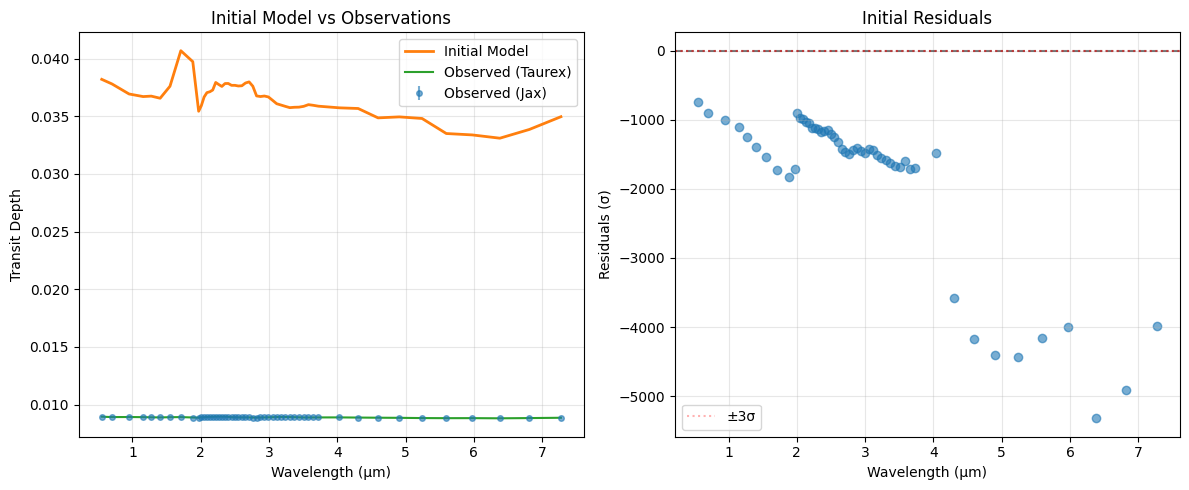

Initial χ²/dof: 4844896.94


In [14]:
# Compare initial model to observations
initial_spectrum = np.array(forward_model(params))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.errorbar(wl_grid, obs_spectrum, yerr=obs_noise, 
             fmt='o', alpha=0.6, markersize=4, label='Observed (Jax)')
plt.plot(wl_grid, initial_spectrum, '-', linewidth=2, label='Initial Model')
plt.plot(wl_grid, taurex_obs_sectrum, label='Observed (Taurex)')
plt.xlabel('Wavelength (μm)')
plt.ylabel('Transit Depth')
plt.title('Initial Model vs Observations')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = (obs_spectrum - initial_spectrum) / obs_noise
plt.scatter(wl_grid, residuals, alpha=0.6)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(3, color='red', linestyle=':', alpha=0.3, label='±3σ')
plt.axhline(-3, color='red', linestyle=':', alpha=0.3)
plt.xlabel('Wavelength (μm)')
plt.ylabel('Residuals (σ)')
plt.title('Initial Residuals')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

chi2_initial = np.sum(residuals**2) / len(residuals)
print(f"Initial χ²/dof: {chi2_initial:.2f}")

## Run Optimization

In [15]:
# Clear any cached compilations to free GPU memory
import gc
jax.clear_caches()
gc.collect()
print("✓ JAX caches cleared")

✓ JAX caches cleared


In [16]:
# Run optimization
# Use chi_squared loss (recommended) to properly weight by observation errors
final_params, losses = fit_with_value_and_grad_adam(
    forward_binned=forward_model,
    observed_y=obs_y,
    observed_err=obs_err,
    init_params=params,
    param_info=param_info,
    fit_params=fit_params,
    steps=N_STEPS,
    lr=LEARNING_RATE,
    clip_norm=1.0,
    print_every=50,
    nan_guard=True,
    loss="chi_squared",  # chi_squared (recommended) weights by errors, mse treats all equal
)

print("\n✓ Optimization complete!")

step    0 | loss=2.42244e+06 | ||grad||=6.341e+06
step   50 | loss=2.07926e+06 | ||grad||=5.642e+06
step  100 | loss=1.78063e+06 | ||grad||=5.017e+06
step  150 | loss=1.52036e+06 | ||grad||=4.457e+06
step  200 | loss=1.29312e+06 | ||grad||=3.953e+06
step  250 | loss=1.09456e+06 | ||grad||=3.496e+06
step  300 | loss=921133 | ||grad||=3.082e+06
step  350 | loss=769887 | ||grad||=2.706e+06
step  400 | loss=638347 | ||grad||=2.364e+06
step  450 | loss=524386 | ||grad||=2.054e+06
step  500 | loss=426141 | ||grad||=1.773e+06
step  550 | loss=341959 | ||grad||=1.519e+06
step  600 | loss=270355 | ||grad||=1.290e+06
step  650 | loss=209989 | ||grad||=1.085e+06
step  700 | loss=159631 | ||grad||=9.014e+05
step  750 | loss=118150 | ||grad||=7.380e+05
step  800 | loss=84524.3 | ||grad||=5.934e+05
step  850 | loss=57817.2 | ||grad||=4.659e+05
step  900 | loss=37173.7 | ||grad||=3.542e+05
step  950 | loss=21815 | ||grad||=2.570e+05
step  999 | loss=11209.6 | ||grad||=1.744e+05

✓ Optimization comple

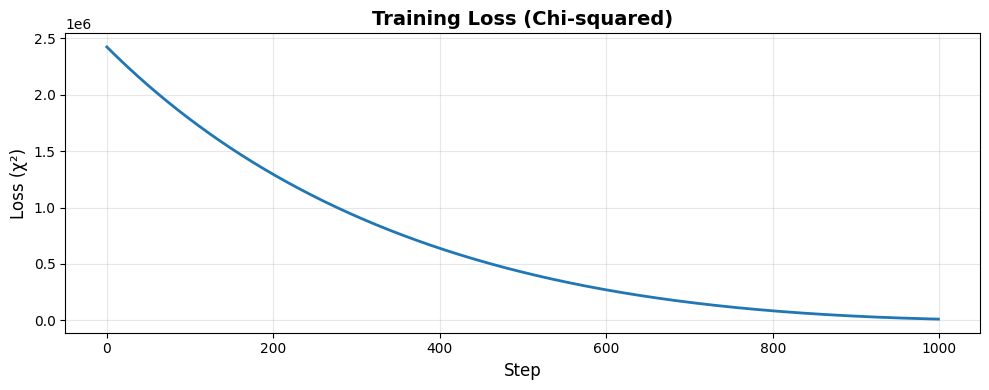

Loss: 2.422438e+06 → 1.120957e+04
Improvement: 216.1x


In [17]:
# Plot loss history
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss (χ²)', fontsize=12)
plt.title('Training Loss (Chi-squared)', fontsize=14, fontweight='bold')
# plt.yscale('log') # can't do log loss with neg losses (:
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss: {losses[0]:.6e} → {losses[-1]:.6e}")
print(f"Improvement: {losses[0] / losses[-1]:.1f}x")

## Compare Results to Ground Truth

In [18]:
# Parameter comparison table
param_mapping = {
    'planet_radius': 'planet_radius',
    'T': 'planet_temp',
    'H2O': 'H2O',
    'CO2': 'CO2',
    'CO': 'CO',
    'CH4': 'CH4',
    'NH3': 'NH3'
}

print("="*80)
print("FITTED vs GROUND TRUTH")
print("="*80)
print(f"{'Parameter':<15} {'Ground Truth':<15} {'Initial':<15} {'Fitted':<15} {'Error %':<10}")
print("-"*80)

comparison = {}
for param, gt_key in param_mapping.items():
    if param in final_params and gt_key in ground_truth:
        gt_val = float(ground_truth[gt_key])
        init_val = float(params[param])
        fit_val = float(final_params[param])
        
        error_pct = abs(fit_val - gt_val) / abs(gt_val) * 100
        initial_error_pct = abs(init_val - gt_val) / abs(gt_val) * 100
        
        comparison[param] = {
            'ground_truth': gt_val,
            'initial': init_val,
            'fitted': fit_val,
            'error_pct': error_pct,
            'improved': error_pct < initial_error_pct
        }
        
        if abs(gt_val) > 1:
            print(f"{param:<15} {gt_val:>14.6f} {init_val:>14.6f} {fit_val:>14.6f} {error_pct:>8.2f}%")
        else:
            print(f"{param:<15} {gt_val:>14.6e} {init_val:>14.6e} {fit_val:>14.6e} {error_pct:>8.2f}%")

print("-"*80)
errors = [v['error_pct'] for v in comparison.values()]
print(f"Mean error: {np.mean(errors):.2f}%, Median: {np.median(errors):.2f}%")

FITTED vs GROUND TRUTH
Parameter       Ground Truth    Initial         Fitted          Error %   
--------------------------------------------------------------------------------
planet_radius     8.638963e-01   1.620780e+00   9.363061e-01     8.38%
T                   945.924548    4253.162782    3035.319322   220.88%
H2O               6.953937e-09   1.161980e-06   6.266149e-08   801.09%
CO2               2.783625e-09   5.582870e-07   1.553212e-08   457.98%
CO                5.222681e-05   1.202545e-07   4.727095e-09    99.99%
CH4               1.834343e-06   2.006400e-06   8.797879e-08    95.20%
NH3               9.976933e-07   1.434596e-07   9.619832e-09    99.04%
--------------------------------------------------------------------------------
Mean error: 254.65%, Median: 99.99%


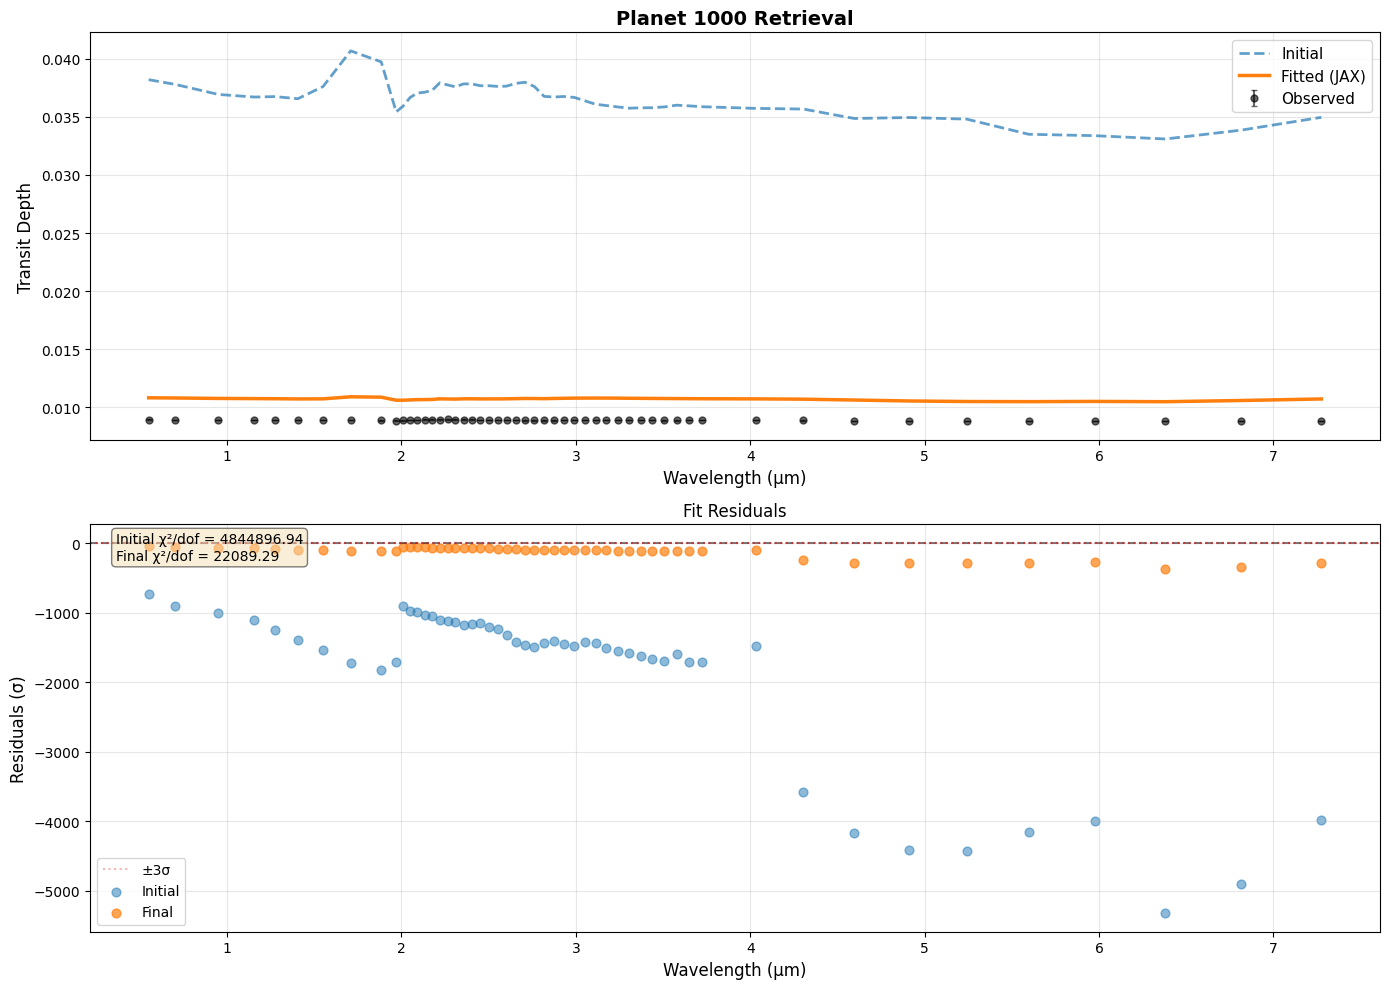


Fit quality: χ²/dof 4844896.94 → 22089.29
RMS residuals: 81.27σ


In [19]:
# Compute fitted spectrum
final_spectrum = np.array(forward_model(final_params))

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Spectra
ax = axes[0]
ax.errorbar(wl_grid, obs_spectrum, yerr=obs_noise, 
            fmt='o', alpha=0.6, markersize=5, color='black',
            label='Observed', capsize=2)
ax.plot(wl_grid, initial_spectrum, '--', linewidth=2, alpha=0.7,
        label='Initial')
ax.plot(wl_grid, final_spectrum, '-', linewidth=2.5,
        label='Fitted (JAX)')
ax.set_xlabel('Wavelength (μm)', fontsize=12)
ax.set_ylabel('Transit Depth', fontsize=12)
ax.set_title(f'Planet {PLANET_ID} Retrieval', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Bottom: Residuals
ax = axes[1]
initial_residuals = (obs_spectrum - initial_spectrum) / obs_noise
final_residuals = (obs_spectrum - final_spectrum) / obs_noise

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.axhline(3, color='red', linestyle=':', alpha=0.3, label='±3σ')
ax.axhline(-3, color='red', linestyle=':', alpha=0.3)

ax.scatter(wl_grid, initial_residuals, alpha=0.5, s=40, label='Initial')
ax.scatter(wl_grid, final_residuals, alpha=0.7, s=40, label='Final')

ax.set_xlabel('Wavelength (μm)', fontsize=12)
ax.set_ylabel('Residuals (σ)', fontsize=12)
ax.set_title('Fit Residuals', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

chi2_final = np.sum(final_residuals**2) / len(final_residuals)
ax.text(0.02, 0.98, f'Initial χ²/dof = {chi2_initial:.2f}\nFinal χ²/dof = {chi2_final:.2f}',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nFit quality: χ²/dof {chi2_initial:.2f} → {chi2_final:.2f}")
print(f"RMS residuals: {np.std(final_residuals):.2f}σ")